---

# JOINTS X INSPIRE 2026: Data Science Competition

*Prakiraan penjualan tiket harian D4 sampai D10 per pasangan film dan klaster bioskop dari tiga hari pertama penayangan, memakai TabPFN-3.5 per horizon dengan prediksi median.*

---

## Nama Tim

- Anggota 1 (Ketua)
- Anggota 2
- Anggota 3

---

## Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**Eksplorasi Data**](#3)
4. [**Preprocessing dan Pembersihan Data**](#4)
5. [**Feature Engineering**](#5)
6. [**Modelling**](#6)
7. [**Evaluasi dan Explainability**](#7)
8. [**Submission dan Kesimpulan**](#8)


---

# Pendahuluan <a name="1"></a>

---

## Overview

*Operator bioskop harus menentukan alokasi layar dan jumlah pertunjukan ketika film baru baru memiliki tiga hari riwayat penjualan. Pola permintaan berbeda antarfilm dan antarklaster bioskop, sehingga perkiraan nasional saja tidak cukup untuk keputusan di tingkat lokasi.*

*Notebook ini membangun seluruh pipeline dari data mentah kompetisi: rekonstruksi sampel latih yang meniru cara panitia membentuk test, feature engineering berbasis temuan EDA, validasi silang per film, pelatihan TabPFN-3.5, evaluasi, dan pembuatan file submission.*

## Aim

*Memprediksi `total_ticket` harian untuk D4 sampai D10 pada setiap pasangan film dan klaster bioskop di `test.csv`, dengan MASE sekecil mungkin pada validasi silang yang dikelompokkan per film (skor OOF sumber 0,29995).*

## Metric

***Mean Absolute Scaled Error (MASE)** membagi galat absolut setiap baris dengan skala pasangannya, yaitu rata-rata tiket D1 sampai D3 (minimal 1). Karena berbasis galat absolut, prediksi optimal per baris adalah median kondisional, bukan rata-rata.*

$$s_p = \max\left(\frac{1}{3}\sum_{d=1}^{3} y_{p,d},\ 1\right) \qquad \text{MASE} = \frac{1}{N}\sum_{i=1}^{N}\frac{|y_i - \hat{y}_i|}{s_{p(i)}}$$

## Dataset

*Data berasal dari kompetisi Kaggle JOINTS X INSPIRE 2026 (datajointsxinspire).*

*`train.csv` berisi 138.959 baris transaksi harian 1 April sampai 30 September 2025, `test_history.csv` berisi 32.323 baris D1 sampai D3 film uji, dan `test.csv` berisi 72.611 baris D4 sampai D10 yang harus diprediksi. Hari tanpa transaksi tidak tercatat sebagai baris.*

*Data digunakan untuk membangun sampel latih D1 sampai D10 dari riwayat train, lalu memprediksi D4 sampai D10 film uji.*

**Attributes**

1.  `date_show`       : Tanggal penayangan
2.  `cinema_ids`      : ID anonim klaster bioskop
3.  `city_name`       : Kota lokasi klaster
4.  `movie_title`     : Judul film, termasuk penanda format (IMAX 2D, 3D)
5.  `occupation_rate` : Persentase kursi terisi, 0 sampai 100
6.  `total_show`      : Jumlah pertunjukan yang terlaksana
7.  `holidays.csv`    : Jenis hari dan hari libur nasional
8.  `movies.csv`      : Metadata film (genre, rating usia)

**Target**
 `total_ticket`       : Jumlah tiket terjual per pasangan per tanggal (0 bila tidak ada transaksi)

## Approach: TabPFN-3.5 per Horizon

*TabPFN-3.5 adalah tabular foundation model yang memprediksi lewat in-context learning: baris latih diberikan sebagai konteks dan model mengeluarkan distribusi prediktif untuk tiap baris uji tanpa pelatihan ulang bobot. Distribusi ini memungkinkan pengambilan median, yang optimal untuk MASE.*

*Satu model dipasang untuk setiap horizon D4 sampai D10. Target dinormalisasi menjadi `y / skala / cal_ratio`, sehingga efek kalender (hari, libur, libur sekolah, Ramadan) sudah dikeluarkan dari target dan dikembalikan saat prediksi.*

```
Transaksi mentah
    |
    +-- Rekonstruksi window D1-D10 (aturan panitia: D1 rilis luas, pasangan laku di D3)
         |
    92 fitur (pasangan, nasional film, relatif pasar, kalender)
         |
    TabPFN-3.5 x 7 horizon (konteks = baris latih horizon yang sama)
         |
    median r_hat x cal_ratio x skala -> total_ticket
```

*Validasi memakai StratifiedGroupKFold 5 fold, group = judul dasar film, strata = bulan D1, karena film menjelaskan 57% variansi target sehingga baris satu film tidak boleh terpecah.*

---

# Inisialisasi <a name="2"></a>

---

## Environment Setup

Notebook dijalankan penuh di GPU lokal NVIDIA RTX 5060 Ti 16 GB (torch 2.14.0+cu130). Seluruh proses CV 5 fold x 7 horizon, pelatihan akhir, dan XAI selesai dalam hitungan menit; puncak VRAM TabPFN-3.5 sekitar 2,5 GB. Untuk uji cepat, set environment variable `NB_SMOKE=1` sebelum menjalankan notebook.

In [1]:
!nvidia-smi

Tue Sep 29 09:09:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:06:00.0  On |                  N/A |
| 31%   43C    P3             15W /  180W |    1613MiB /  16311MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The following cell installs all libraries used in this notebook. Versi di-pin sama dengan environment lokal. torch tidak di-pin di sini karena build CUDA bergantung pada platform (lokal memakai torch 2.14.0 dari index cu130).

In [2]:
%pip install -q numpy==2.4.6 pandas==3.0.3 scikit-learn==1.7.2 matplotlib==3.10.8 tabpfn==9.0.0 huggingface_hub==1.28.0 safetensors==0.8.0

Note: you may need to restart the kernel to use updated packages.


## Import Libraries

Seluruh import notebook dikumpulkan di sini.

In [3]:
import hashlib
import os
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import hf_hub_download
from sklearn.model_selection import StratifiedGroupKFold
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
print('torch', torch.__version__, '| cuda', torch.cuda.is_available())

torch 2.14.0+cu130 | cuda True


## Seed Everything

Seed dikunci di semua sumber acak (Python, NumPy, PyTorch, cuBLAS). Nilai seed 2026 mengikuti contoh panitia dan sama dengan eksperimen sumber, sehingga fold dan subsampling internal TabPFN identik. Algoritma deterministik PyTorch tidak dipaksa karena beberapa kernel attention TabPFN tidak memiliki versi deterministik; selisih antar GPU berada di orde 1e-5 pada MASE.

In [4]:
def seed_everything(seed: int = 2026, deterministic: bool = True) -> int:
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        torch.use_deterministic_algorithms(True)
    return seed


def prediction_hash(pred) -> str:
    arr = np.ascontiguousarray(np.round(np.asarray(pred, dtype=np.float64), 6))
    return hashlib.sha256(arr.tobytes()).hexdigest()[:16]


SEED = seed_everything(2026, deterministic=False)

## Settings

Semua path, hyperparameter, dan flag dikumpulkan di sini. Saat pindah ke Kaggle atau Colab, cukup ubah `DATA_DIR`, `CACHE_DIR`, dan `OUTPUT_DIR`. `CACHE_DIR` berisi bobot TabPFN-3.5; bila file belum ada, bobot diunduh dari Hugging Face Hub (`Prior-Labs/tabpfn_3_5`, repo ber-lisensi sehingga butuh `HF_TOKEN` dari akun yang sudah menyetujui lisensi Prior Labs).

In [5]:
class Settings:
    SEED         = 2026
    DATA_DIR     = Path('E:/datsci/joint/joints/data')
    CACHE_DIR    = Path('D:/cache_moved/tabpfn')
    OUTPUT_DIR   = Path('E:/datsci/joint/joints/notebooks/output_tabpfn35')
    FIG_DIR      = OUTPUT_DIR / 'figures'

    TABPFN_REPO  = 'Prior-Labs/tabpfn_3_5'
    TABPFN_FILE  = 'tabpfn-v3.5-20260909.safetensors'
    HF_TOKEN     = os.environ.get('HF_TOKEN')
    DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

    N_FOLDS      = 5
    HORIZONS     = list(range(4, 11))
    N_ESTIMATORS = 8
    OUTPUT_TYPE  = 'median'
    FRAC_WIDE    = 0.5
    MIN_NC       = 25
    MARKET_DAYS  = 28

    RUN_XAI      = True
    XAI_HORIZON  = 8
    SMOKE_TEST   = os.environ.get('NB_SMOKE', '0') == '1'
    SMOKE_FILMS  = 30


CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)
print('device:', CFG.DEVICE, '| smoke test:', CFG.SMOKE_TEST)

device: cuda | smoke test: False


## Load Dataset

Semua file resmi kompetisi dibaca. Tidak ada artefak eksperimen atau file fold yang dimuat; fold dibuat ulang di bagian 5.

In [6]:
train = pd.read_csv(CFG.DATA_DIR / 'train.csv', parse_dates=['date_show'])
test_history = pd.read_csv(CFG.DATA_DIR / 'test_history.csv', parse_dates=['date_show'])
test = pd.read_csv(CFG.DATA_DIR / 'test.csv', parse_dates=['date_show'])
holidays = pd.read_csv(CFG.DATA_DIR / 'holidays.csv', parse_dates=['date'])
movies = pd.read_csv(CFG.DATA_DIR / 'movies.csv')
sample_submission = pd.read_csv(CFG.DATA_DIR / 'sample_submission.csv')

for name, df in [('train', train), ('test_history', test_history), ('test', test),
                 ('holidays', holidays), ('movies', movies), ('sample_submission', sample_submission)]:
    print(f'{name:18s} {str(df.shape):14s} kolom: {list(df.columns)}')

train              (138959, 7)    kolom: ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test_history       (32323, 7)     kolom: ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test               (72611, 5)     kolom: ['id', 'movie_title', 'cinema_ids', 'city_name', 'date_show']
holidays           (366, 4)       kolom: ['date', 'day_tipe', 'holiday_tipe', 'holiday_name']
movies             (397, 7)       kolom: ['original_title', 'age_rating', 'genre', 'producer', 'director', 'writer', 'casts']
sample_submission  (72611, 2)     kolom: ['id', 'total_ticket']


---

# Eksplorasi Data <a name="3"></a>

---

Eksplorasi difokuskan pada pertanyaan yang langsung mengubah keputusan pipeline: bagaimana panitia membentuk test, apakah ada data rusak, seberapa besar efek kalender, dan apakah periode test (Oktober 2025 sampai Maret 2026) berbeda dari train (April sampai September 2025).

## Ringkasan Data

Rentang tanggal, jumlah entitas, dan keberadaan baris bernilai nol diperiksa lebih dulu. Baris nol menentukan apakah hari tanpa transaksi harus diisi sendiri saat membentuk target.

In [7]:
summary = pd.DataFrame({
    'mulai': [train.date_show.min().date(), test_history.date_show.min().date(), test.date_show.min().date()],
    'selesai': [train.date_show.max().date(), test_history.date_show.max().date(), test.date_show.max().date()],
    'film': [train.movie_title.nunique(), test_history.movie_title.nunique(), test.movie_title.nunique()],
    'klaster': [train.cinema_ids.nunique(), test_history.cinema_ids.nunique(), test.cinema_ids.nunique()],
    'kota': [train.city_name.nunique(), test_history.city_name.nunique(), test.city_name.nunique()],
}, index=['train', 'test_history', 'test'])
print(summary)
print('\nbaris tiket = 0 di train:', int((train.total_ticket == 0).sum()))
print('duplikat (tanggal, klaster, film) di train:', int(train.duplicated(['date_show', 'cinema_ids', 'movie_title']).sum()))
print('pasangan test x baris:', test.groupby(['movie_title', 'cinema_ids']).size().value_counts().to_dict())

                   mulai     selesai  film  klaster  kota
train         2025-04-01  2025-09-30   237      117    67
test_history  2025-10-01  2026-03-20   163      121    69
test          2025-10-04  2026-03-27   160      121    69

baris tiket = 0 di train: 0
duplikat (tanggal, klaster, film) di train: 0
pasangan test x baris: {7: 10373}


#### Insights

> Train tidak memiliki satu pun baris bertiket 0, sehingga hari tanpa transaksi memang tidak tercatat dan target D4 sampai D10 harus diisi 0 secara eksplisit. Setiap pasangan test memiliki tepat tujuh baris (D4 sampai D10).

> Periode test mencakup Oktober 2025 sampai Maret 2026, bukan hanya Desember. Periode ini memuat musim sepi Oktober, libur Natal dan tahun baru, Ramadan, dan minggu Idulfitri yang tidak ada padanannya di train.

## Aturan Panitia Membentuk Test

`test_history` berisi 11.823 pasangan, tetapi `test.csv` hanya 10.373. Pasangan yang dibuang dibandingkan menurut hari terakhir pasangan itu masih bertransaksi di D1 sampai D3, dan hari D1 film uji dibandingkan dengan hari rilis luas film di train.

proporsi pasangan masuk test menurut hari terakhir laku:
               mean   size
hari_terakhir             
1               0.0    514
2               0.0    936
3               1.0  10373


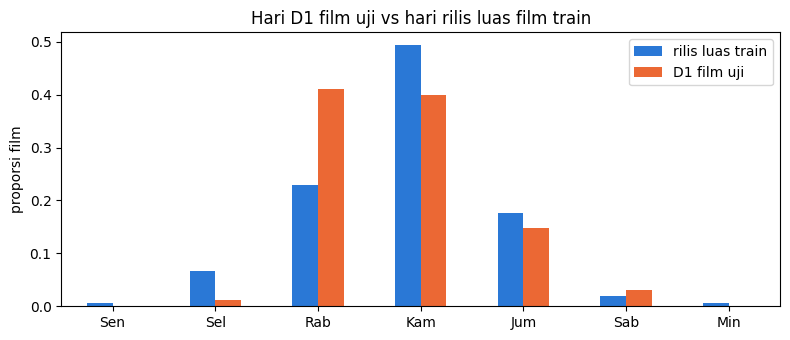

In [8]:
th = test_history.copy()
th['D1'] = th.groupby('movie_title').date_show.transform('min')
th['d'] = (th.date_show - th.D1).dt.days + 1
pairs_hist = th.groupby(['movie_title', 'cinema_ids']).d.max().rename('hari_terakhir').reset_index()
pairs_test = test[['movie_title', 'cinema_ids']].drop_duplicates().assign(masuk_test=1)
pairs_hist = pairs_hist.merge(pairs_test, how='left').fillna({'masuk_test': 0})
print('proporsi pasangan masuk test menurut hari terakhir laku:')
print(pairs_hist.groupby('hari_terakhir').masuk_test.agg(['mean', 'size']))

nat = train.groupby(['movie_title', 'date_show']).cinema_ids.nunique().rename('n_cin').reset_index()
nat['peak'] = nat.groupby('movie_title').n_cin.transform('max')
wide_day = nat[(nat.n_cin >= 0.5 * nat.peak) & (nat.peak >= 25)].groupby('movie_title').date_show.min()
dow_names = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']
dow_cmp = pd.DataFrame({
    'rilis luas train': wide_day.dt.dayofweek.value_counts(normalize=True),
    'D1 film uji': th.drop_duplicates('movie_title').D1.dt.dayofweek.value_counts(normalize=True),
}).reindex(range(7)).fillna(0)
dow_cmp.index = dow_names

fig, ax = plt.subplots(figsize=(8, 3.5))
dow_cmp.plot.bar(ax=ax, rot=0, color=['#2a78d6', '#eb6834'])
ax.set_ylabel('proporsi film')
ax.set_title('Hari D1 film uji vs hari rilis luas film train')
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'eda_d1_dow.png', dpi=110)
plt.show()

#### Insights

> Pasangan masuk test jika dan hanya jika masih bertransaksi di D3: proporsinya 1,0 untuk hari terakhir D3 dan 0,0 untuk D1 atau D2. Sampel latih wajib memakai aturan yang sama.

> D1 film uji jatuh terutama pada Rabu dan Kamis, sama seperti hari rilis luas di train. D1 adalah tanggal rilis resmi, bukan transaksi pertama: sebagian film memiliki preview di 1 sampai 2 klaster atau akhir pekan preview sebelum rilis, dan hari-hari itu tidak dimasukkan panitia.

## Hari dengan Data Hilang

Jumlah klaster yang melapor per hari diperiksa untuk menemukan gangguan pengumpulan data. Hari seperti itu akan terbaca sebagai film dicabut (target 0 palsu) bila tidak ditangani.

            n_cin  baris   tiket
date_show                       
2025-06-05    115    656   60064
2025-06-06    105    747  217984
2025-06-07     10     10    4981
2025-06-08    115    665  199056
2025-06-09      1      1     157
2025-06-10     67    449   69707
2025-06-11     76    136   43555
2025-06-12    112    718  129269
2025-06-13      0      0       0
2025-06-14     83    169   72698
2025-06-15     87    326  152257
2025-06-16     62    404   61041
2025-06-17    116    899  155759


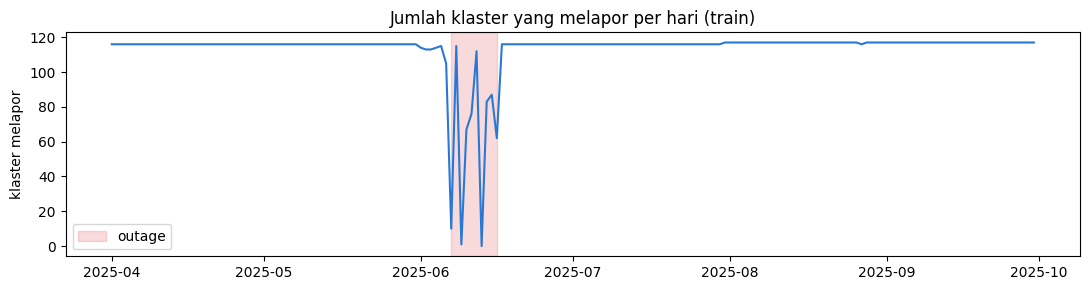

In [9]:
daily = train.groupby('date_show').agg(n_cin=('cinema_ids', 'nunique'), baris=('movie_title', 'size'),
                                       tiket=('total_ticket', 'sum')).asfreq('D').fillna(0)
print(daily.loc['2025-06-05':'2025-06-17'].astype(int))

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(daily.index, daily.n_cin, color='#2a78d6')
ax.axvspan(pd.Timestamp('2025-06-07'), pd.Timestamp('2025-06-16'), color='#e34948', alpha=0.2, label='outage')
ax.set_ylabel('klaster melapor')
ax.set_title('Jumlah klaster yang melapor per hari (train)')
ax.legend()
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'eda_outage.png', dpi=110)
plt.show()

#### Insights

> Pada 7 sampai 16 Juni 2025 sebagian besar klaster tidak melapor (13 Juni 0 klaster, 9 Juni 1 klaster) padahal normalnya 116. Window yang bersinggungan dengan periode ini dibuang agar tidak ada target nol palsu. Penurunan 25 Agustus sampai 2 September bersifat nyata karena semua klaster tetap melapor.

## Efek Kalender

Total tiket nasional per hari dibandingkan dengan rata-rata minggunya untuk mengukur efek hari dan hari libur. Angka ini menjadi bobot kalender yang menormalkan target di bagian 5.

pengali hari (vs rata-rata minggu): {'Sen': 0.847, 'Sel': 0.745, 'Rab': 0.85, 'Kam': 0.973, 'Jum': 0.99, 'Sab': 1.359, 'Min': 1.229}
                                         holiday_name  pengali
date_show                                                     
2025-04-01                           Idulfitri 1446 H     1.05
2025-04-18                        Wafat Yesus Kristus     1.48
2025-04-20         Kebangkitan Yesus Kristus (Paskah)     0.91
2025-05-01                   Hari Buruh Internasional     1.77
2025-05-12                   Hari Raya Waisak 2569 BE     1.61
2025-05-29                     Kenaikan Yesus Kristus     1.94
2025-06-01                       Hari Lahir Pancasila     0.33
2025-06-06                           Idul Adha 1446 H     3.22
2025-06-27          1 Muharam Tahun Baru Islam 1447 H     1.31
2025-08-17  Proklamasi Kemerdekaan Republik Indonesia     1.38
2025-09-05                   Maulid Nabi Muhammad SAW     2.19


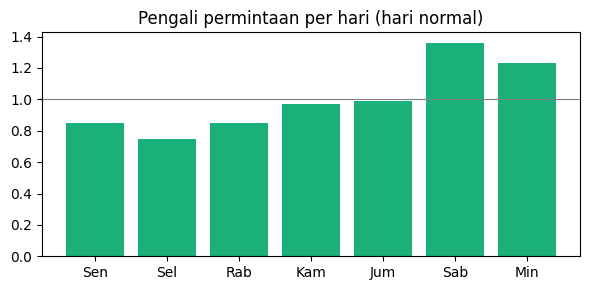

In [10]:
nat_day = train.groupby('date_show').total_ticket.sum().rename('tiket').to_frame()
nat_day = nat_day[~nat_day.index.to_series().between('2025-06-07', '2025-06-16')]
nat_day['dow'] = nat_day.index.dayofweek
nat_day['minggu'] = nat_day.index.to_period('W-SUN')
nat_day['dev'] = np.log(nat_day.tiket) - np.log(nat_day.tiket).groupby(nat_day.minggu).transform('mean')
hol_dates = set(holidays.loc[holidays.holiday_tipe == 'holiday', 'date'])
normal = nat_day[~nat_day.index.isin(hol_dates)]
dow_mult = np.exp(normal.groupby('dow').dev.median())
print('pengali hari (vs rata-rata minggu):', dow_mult.round(3).rename(index=dict(enumerate(dow_names))).to_dict())
hol_rows = nat_day[nat_day.index.isin(hol_dates)].copy()
hol_rows['pengali'] = np.exp(hol_rows.dev - hol_rows.dow.map(np.log(dow_mult)))
print(hol_rows.join(holidays.set_index('date').holiday_name)[['holiday_name', 'pengali']].round(2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(dow_names, dow_mult.values, color='#1baf7a')
ax.axhline(1, color='gray', lw=0.8)
ax.set_title('Pengali permintaan per hari (hari normal)')
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'eda_dow.png', dpi=110)
plt.show()

#### Insights

> Sabtu sekitar 1,36 dan Minggu 1,23 kali rata-rata minggu, sedangkan Selasa hanya 0,75. Libur yang jatuh di hari kerja menaikkan permintaan 1,5 sampai 2,2 kali (Hari Buruh 1,77, Kenaikan 1,94, Maulid 2,19), sedangkan libur di hari Minggu hampir tidak menambah (Paskah 0,91). Karena skala MASE dihitung dari D1 sampai D3 yang komposisi harinya berbeda antarfilm, target dinormalisasi dengan rasio bobot kalender tanggal target terhadap D1 sampai D3.

> `holidays.csv` tidak memuat cuti bersama dan libur sekolah. Keduanya ditambahkan dari sumber publik yang terbit sebelum 30 September 2025: SKB 3 Menteri cuti bersama 2025 (Oktober 2024) dan 2026 (ditetapkan 19 September 2025), serta kalender pendidikan DKI Jakarta 2024/2025 dan 2025/2026.

## Pergeseran Train vs Test

Okupansi median per bulan dibandingkan antara train dan `test_history`. Jika level permintaan berbeda, fitur relatif terhadap pasar lebih aman daripada fitur level absolut.

sumber     test_history  train
date_show                     
2025-04             NaN   41.8
2025-05             NaN   21.8
2025-06             NaN   20.3
2025-07             NaN   23.7
2025-08             NaN   19.1
2025-09             NaN   13.6
2025-10             7.6    NaN
2025-11            13.2    NaN
2025-12            25.2    NaN
2026-01            13.6    NaN
2026-02             5.5    NaN
2026-03             6.4    NaN


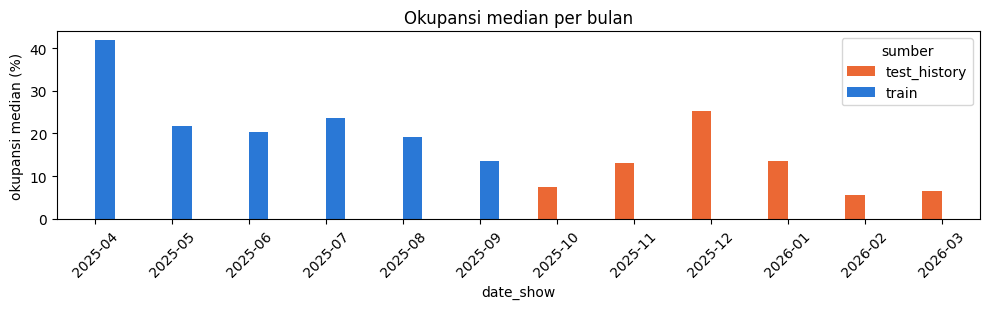

In [11]:
occ_month = pd.concat([
    train.assign(sumber='train').groupby([train.date_show.dt.to_period('M'), 'sumber']).occupation_rate.median(),
    test_history.assign(sumber='test_history').groupby([test_history.date_show.dt.to_period('M'), 'sumber']).occupation_rate.median(),
]).unstack()
print(occ_month.round(1))

fig, ax = plt.subplots(figsize=(10, 3.2))
occ_month.plot.bar(ax=ax, rot=45, color=['#eb6834', '#2a78d6'])
ax.set_ylabel('okupansi median (%)')
ax.set_title('Okupansi median per bulan')
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'eda_shift.png', dpi=110)
plt.show()

#### Insights

> Okupansi median test pada Oktober (7,6%), Februari (5,5%), dan Maret (6,4%, Ramadan) berada di bawah seluruh bulan train (13,6% sampai 41,8%), sedangkan Desember (25,2%) setara bulan train. Bentuk kurva (tren D1 sampai D3, pola hari) tidak bergeser, yang bergeser adalah level pasar. Karena itu fitur okupansi dan tiket per show juga dibuat dalam versi relatif terhadap median film yang rilis 28 hari sebelumnya (hanya data masa lalu).

---

# Preprocessing dan Pembersihan Data <a name="4"></a>

---

`train.csv` adalah riwayat transaksi mentah, bukan tabel sampel D1 sampai D10. Bagian ini merekonstruksi sampel latih dengan aturan yang sama seperti panitia membentuk test, lalu membersihkan window yang rusak karena outage atau akhir pekan preview.

## Rekonstruksi Window D1 sampai D10

D1 dihitung per judul dasar (varian 2D, 3D, dan IMAX berbagi D1 seperti di `test_history`) sebagai hari pertama cakupan klaster mencapai 50% puncak, di dalam segmen tayang kontinu yang memuat puncak. Aturan segmen kontinu mencegah akhir pekan preview berbayar (misalnya A MINECRAFT MOVIE 4 sampai 6 April dengan rilis resmi 9 April, atau FINAL DESTINATION 9 sampai 10 Mei dengan rilis 14 Mei) terbaca sebagai D1. Judul dengan cakupan D1 di bawah 25 klaster dibuang karena test hanya berisi rilis luas. Pasangan dipakai bila bertransaksi di D3, dan target D4 sampai D10 yang tidak memiliki baris diisi 0.

In [12]:
FMT_RE = r'\s*\((IMAX 2D|IMAX 3D|3D|REISSUE|4DX|SCREENX)\)\s*$'
OUTAGE = (pd.Timestamp('2025-06-07'), pd.Timestamp('2025-06-16'))


def base_title_strip(s):
    return s.str.replace(FMT_RE, '', regex=True).str.strip()


def film_d1(df, frac=CFG.FRAC_WIDE, min_nc=CFG.MIN_NC):
    x = df.assign(base=base_title_strip(df.movie_title))
    nc = x.groupby(['base', 'date_show']).cinema_ids.nunique()
    d1_base = {}
    for b, s in nc.groupby(level=0):
        s = s.droplevel(0)
        s = s.reindex(pd.date_range(s.index.min(), s.index.max()), fill_value=0)
        peak_day = s.idxmax()
        zero_before = s[:peak_day][s[:peak_day] == 0]
        seg_start = zero_before.index.max() + pd.Timedelta(days=1) if len(zero_before) else s.index.min()
        seg = s[seg_start:]
        cand = seg[seg >= frac * s.max()]
        if len(cand) and cand.iloc[0] >= min_nc:
            d1_base[b] = cand.index[0]
    d1_base = pd.Series(d1_base)
    t = x.drop_duplicates('movie_title').set_index('movie_title').base
    return t.map(d1_base).dropna().rename('D1')


def long_to_windows(hist, d1):
    h = hist.merge(d1.reset_index(), on='movie_title')
    h['d'] = (h.date_show - h.D1).dt.days + 1
    h13 = h[(h.d >= 1) & (h.d <= 3)]
    pairs = h13[h13.d == 3][['movie_title', 'cinema_ids']].drop_duplicates()
    h13 = h13.merge(pairs)
    wide = h13.pivot_table(index=['movie_title', 'cinema_ids', 'city_name'], columns='d',
                           values=['total_ticket', 'occupation_rate', 'total_show'], fill_value=0)
    wide.columns = [f'{a}_d{b}' for a, b in wide.columns]
    wide = wide.reset_index()
    for c in ['total_ticket', 'occupation_rate', 'total_show']:
        for k in (1, 2, 3):
            if f'{c}_d{k}' not in wide:
                wide[f'{c}_d{k}'] = 0.0
    wide['scale'] = np.maximum(wide[['total_ticket_d1', 'total_ticket_d2', 'total_ticket_d3']].sum(axis=1) / 3, 1)
    return wide.merge(d1.reset_index(), on='movie_title')


def build_windows(tr, frac=CFG.FRAC_WIDE, min_nc=CFG.MIN_NC, exclude_outage=True):
    d1 = film_d1(tr, frac, min_nc)
    start, end = tr.date_show.min(), tr.date_show.max()
    d1 = d1[(d1 > start) & (d1 + pd.Timedelta(days=9) <= end)]
    first = tr.groupby(base_title_strip(tr.movie_title)).date_show.min()
    d1 = d1[first.reindex(base_title_strip(pd.Series(d1.index))).values > start]
    if exclude_outage:
        d1 = d1[~((d1 <= OUTAGE[1]) & (d1 + pd.Timedelta(days=9) >= OUTAGE[0]))]
    wide = long_to_windows(tr, d1)
    tgt = wide[['movie_title', 'cinema_ids', 'D1']].copy()
    tgt = tgt.loc[tgt.index.repeat(7)].reset_index(drop=True)
    tgt['d'] = np.tile(np.arange(4, 11), len(wide))
    tgt['date_show'] = tgt.D1 + pd.to_timedelta(tgt.d - 1, unit='D')
    tgt = tgt.merge(tr[['movie_title', 'cinema_ids', 'date_show', 'total_ticket', 'occupation_rate', 'total_show']],
                    how='left', on=['movie_title', 'cinema_ids', 'date_show'])
    tgt[['total_ticket', 'occupation_rate', 'total_show']] = tgt[['total_ticket', 'occupation_rate', 'total_show']].fillna(0)
    return wide, tgt


def test_windows(th):
    d1 = th.groupby(base_title_strip(th.movie_title)).date_show.min()
    t = th.drop_duplicates('movie_title').set_index('movie_title')
    d1 = base_title_strip(pd.Series(t.index, index=t.index)).map(d1).rename('D1')
    return long_to_windows(th, d1)

Window dibangun untuk train dan test, lalu kesesuaiannya dengan test diperiksa: pasangan test hasil rekonstruksi harus identik dengan pasangan di `test.csv`, dan proporsi jumlah hari hadir D1 sampai D3 harus mirip.

In [13]:
wide, tgt = build_windows(train)
tw = test_windows(test_history)
pairs_check = tw[['movie_title', 'cinema_ids']].merge(test[['movie_title', 'cinema_ids']].drop_duplicates())
assert len(pairs_check) == len(tw) == test.groupby(['movie_title', 'cinema_ids']).ngroups

def days_present(w):
    return (w[['total_ticket_d1', 'total_ticket_d2', 'total_ticket_d3']] > 0).sum(axis=1).value_counts(normalize=True).sort_index().round(3)

print(f'train: {wide.movie_title.nunique()} film, {len(wide)} pasangan, {len(tgt)} baris target')
print(f'test : {tw.movie_title.nunique()} film, {len(tw)} pasangan')
print(pd.DataFrame({'train': days_present(wide), 'test': days_present(tw)}))

train: 141 film, 7988 pasangan, 55916 baris target
test : 160 film, 10373 pasangan
   train   test
1  0.016  0.018
2  0.055  0.070
3  0.929  0.911


## Pola Nol dan Siklus Program Mingguan

Target D4 sampai D10 yang bernilai nol dianalisis menurut hari D1 untuk melihat kapan film dicabut dari layar. Pola ini menjadi dasar fitur jumlah Rabu dan Kamis yang dilewati.

d       4      5      6      7      8      9      10
Rab  0.050  0.081  0.088  0.109  0.287  0.404  0.450
Kam  0.081  0.126  0.173  0.279  0.409  0.496  0.533
Jum  0.142  0.240  0.511  0.645  0.725  0.723  0.715


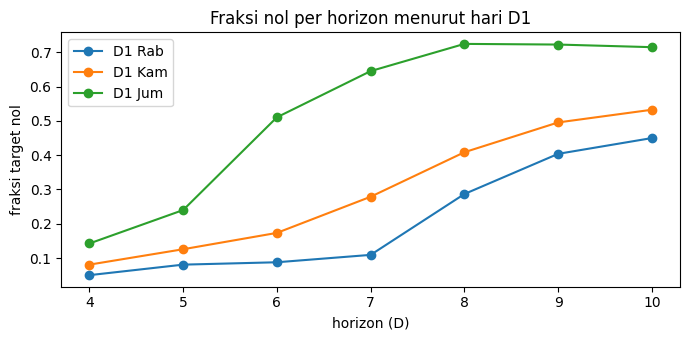

In [14]:
zero = tgt.assign(nol=(tgt.total_ticket == 0).astype(int), d1_dow=tgt.D1.dt.dayofweek)
zero_tab = zero[zero.d1_dow.isin([2, 3, 4])].pivot_table(index='d1_dow', columns='d', values='nol', aggfunc='mean')
zero_tab.index = [dow_names[i] for i in zero_tab.index]
print(zero_tab.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, row in zero_tab.iterrows():
    ax.plot(row.index, row.values, marker='o', label=f'D1 {name}')
ax.set_xlabel('horizon (D)')
ax.set_ylabel('fraksi target nol')
ax.set_title('Fraksi nol per horizon menurut hari D1')
ax.legend()
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'prepro_zero_cycle.png', dpi=110)
plt.show()

#### Insights

> Rekonstruksi menghasilkan 141 film rilis luas, 7.988 pasangan, dan 55.916 baris target, dengan proporsi hari hadir D1 sampai D3 yang hampir sama dengan test (sekitar 93% vs 91% hadir tiga hari).

> Fraksi nol melonjak saat window melewati Rabu atau Kamis minggu berikutnya, yaitu hari rilis film baru: film yang rilis Rabu naik tajam di D8, film yang rilis Jumat sudah naik di D6. Film dicabut pada pergantian program, bukan meluruh perlahan, sehingga fitur kalender pergantian program lebih informatif daripada horizon saja.

---

# Feature Engineering <a name="5"></a>

---

Fitur dibangun di tingkat pasangan dari D1 sampai D3, lalu diperluas ke tujuh baris target. Semua fitur hanya memakai informasi yang tersedia di D3 film tersebut, sehingga fitur yang sama bisa dihitung untuk test tanpa melihat masa depan.

## Kalender Eksternal dan Bobot Kalender

Pengali hari berasal dari analisis efek kalender (Selasa 0,77 sampai Sabtu 1,38). Libur di hari kerja diberi pengali 1,7 (minimal setara Sabtu) di luar Ramadan, karena cuti bersama di akhir Ramadan adalah masa mudik. Hari kerja Senin sampai Kamis saat libur sekolah diberi pengali 1,15. Semua tanggal eksternal terbit sebelum 30 September 2025 sesuai aturan data eksternal.

In [15]:
DOW_MULT = {0: 0.847, 1: 0.765, 2: 0.906, 3: 0.993, 4: 0.99, 5: 1.381, 6: 1.272}
HOL_WEEKDAY_MULT = 1.7
SCHOOL_WEEKDAY_MULT = 1.15
CUTI_BERSAMA = pd.to_datetime(['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-07', '2025-05-13', '2025-05-30',
                               '2025-06-09', '2025-08-18', '2025-12-26', '2026-02-16', '2026-03-18', '2026-03-20',
                               '2026-03-23', '2026-03-24'])
SCHOOL_BREAKS = [('2025-06-28', '2025-07-12'), ('2025-12-22', '2026-01-03')]
RAMADAN = (pd.Timestamp('2026-02-19'), pd.Timestamp('2026-03-20'))
LEBARAN = pd.Timestamp('2026-03-21')
HOL_SET = set(holidays[holidays.holiday_tipe == 'holiday'].date) | set(CUTI_BERSAMA)


def in_school(d):
    return np.any([(d >= pd.Timestamp(a)) & (d <= pd.Timestamp(b)) for a, b in SCHOOL_BREAKS], axis=0)


def in_ramadan(d):
    return (d >= RAMADAN[0]) & (d <= RAMADAN[1])


def base_title(s):
    return s.str.replace(FMT_RE, '', regex=True)


def fmt_of(s):
    return s.str.extract(r'\(([^)]*)\)\s*$')[0].fillna('REG')


def cal_weight(dates, hol_set):
    dow = dates.dt.dayofweek
    w = dow.map(DOW_MULT).astype(float).values
    school = in_school(dates.values)
    ram = in_ramadan(dates.values)
    w = np.where(school & (dow.values < 4), w * SCHOOL_WEEKDAY_MULT, w)
    is_hol = dates.isin(hol_set).values
    w = np.where(is_hol & (dow.values < 5) & ~ram, np.maximum(w * HOL_WEEKDAY_MULT, DOW_MULT[5]), w)
    return pd.Series(w, index=dates.index)

## Fitur Pasangan dan Film

Fitur dikelompokkan menjadi lima jenis: level dan tren tiket, okupansi, serta jumlah show pasangan di D1 sampai D3; agregat nasional film (film menjelaskan 57% variansi target, klaster hanya 2%); tren yang disesuaikan kalender; posisi pasangan relatif terhadap filmnya (share, tiket per show relatif); dan sinyal kota dari klaster lain yang menayangkan film yang sama.

In [16]:
def pair_features(w, hol_set):
    f = w[['movie_title', 'cinema_ids', 'city_name', 'D1', 'scale']].copy()
    for c, a in [('total_ticket', 'tix'), ('occupation_rate', 'occ'), ('total_show', 'show')]:
        for k in (1, 2, 3):
            f[f'{a}_d{k}'] = w[f'{c}_d{k}'].astype(float)
    tix = f[['tix_d1', 'tix_d2', 'tix_d3']].values
    f['days_present'] = (tix > 0).sum(axis=1)
    f['first_day'] = np.argmax(tix > 0, axis=1) + 1
    f['log_scale'] = np.log(f.scale)
    f['tix_r21'] = (f.tix_d2 + 1) / (f.tix_d1 + 1)
    f['tix_r32'] = (f.tix_d3 + 1) / (f.tix_d2 + 1)
    f['tix_r31'] = (f.tix_d3 + 1) / (f.tix_d1 + 1)
    f['show_r31'] = (f.show_d3 + 1) / (f.show_d1 + 1)
    for k in (1, 2, 3):
        f[f'tps_d{k}'] = w[f'total_ticket_d{k}'] / w[f'total_show_d{k}'].clip(lower=1)
    f['occ13'] = w[['occupation_rate_d1', 'occupation_rate_d2', 'occupation_rate_d3']].mean(axis=1)
    f['seats_per_show'] = (w.total_ticket_d3 / (w.occupation_rate_d3 / 100).clip(lower=1e-3)
                           / w.total_show_d3.clip(lower=1)).where(w.occupation_rate_d3 > 1)
    cw = np.stack([cal_weight(w.D1 + pd.Timedelta(days=k), hol_set).values for k in range(3)], axis=1)
    f['cal_w13'] = cw.mean(axis=1)
    f['n_hol_d13'] = sum((w.D1 + pd.Timedelta(days=k)).isin(hol_set).astype(int) for k in range(3))
    f['n_school_d13'] = sum(in_school((w.D1 + pd.Timedelta(days=k)).values).astype(int) for k in range(3))
    f['n_ramadan_d13'] = sum(in_ramadan((w.D1 + pd.Timedelta(days=k)).values).astype(int) for k in range(3))
    g = w.groupby('movie_title')
    for k in (1, 2, 3):
        f[f'nat_tix_d{k}'] = g[f'total_ticket_d{k}'].transform('sum')
        f[f'nat_show_d{k}'] = g[f'total_show_d{k}'].transform('sum')
        f[f'n_cin_d{k}'] = g[f'total_ticket_d{k}'].transform(lambda s: (s > 0).sum())
    f['n_pairs'] = g.scale.transform('size')
    f['nat_tix_r31'] = (f.nat_tix_d3 + 1) / (f.nat_tix_d1 + 1)
    f['nat_show_r31'] = (f.nat_show_d3 + 1) / (f.nat_show_d1 + 1)
    f['nat_tps_d3'] = f.nat_tix_d3 / f.nat_show_d3.clip(lower=1)
    f['nat_occ13'] = g.occupation_rate_d3.transform('median')
    f['share_d3'] = f.tix_d3 / f.nat_tix_d3.clip(lower=1)
    f['tix_r31_vs_nat'] = f.tix_r31 / f.nat_tix_r31
    f['show_r31_vs_nat'] = f.show_r31 / f.nat_show_r31
    f['occ13_vs_film'] = f.occ13 / g.occupation_rate_d3.transform('median').clip(lower=0.1)
    cwk = {k: cal_weight(w.D1 + pd.Timedelta(days=k - 1), hol_set).values for k in (1, 2, 3)}
    for k in (1, 2, 3):
        f[f'tix_adj_d{k}'] = f[f'tix_d{k}'] / cwk[k]
        f[f'nat_tix_adj_d{k}'] = f[f'nat_tix_d{k}'] / cwk[k]
    f['tix_adj_r31'] = (f.tix_adj_d3 + 1) / (f.tix_adj_d1 + 1)
    f['tix_adj_r32'] = (f.tix_adj_d3 + 1) / (f.tix_adj_d2 + 1)
    f['nat_tix_adj_r31'] = (f.nat_tix_adj_d3 + 1) / (f.nat_tix_adj_d1 + 1)
    f['nat_tix_adj_r32'] = (f.nat_tix_adj_d3 + 1) / (f.nat_tix_adj_d2 + 1)
    f['tix_adj_r31_vs_nat'] = f.tix_adj_r31 / f.nat_tix_adj_r31
    f['scale_adj'] = np.log1p((f.tix_adj_d1 + f.tix_adj_d2 + f.tix_adj_d3) / 3)
    f['tps_d3_vs_nat'] = f.tps_d3 / f.nat_tps_d3.clip(lower=0.1)
    f['occ_d3_vs_nat'] = f.occ_d3 / f.nat_occ13.clip(lower=0.1)
    f['footprint_r31'] = f.n_cin_d3 / f.n_cin_d1.clip(lower=1)
    f['show_share_d3'] = f.show_d3 / f.nat_show_d3.clip(lower=1)
    f['show_share_r31'] = f.show_share_d3 / (f.show_d1 / f.nat_show_d1.clip(lower=1)).clip(lower=1e-4)
    gc = f.groupby(['movie_title', 'city_name'])
    n_city = gc.tix_d3.transform('size')
    f['city_n_cin'] = n_city
    f['city_tix_r31_other'] = ((gc.tix_d3.transform('sum') - f.tix_d3 + 1) / (gc.tix_d1.transform('sum') - f.tix_d1 + 1)).where(n_city > 1)
    f['city_share_d3'] = f.tix_d3 / gc.tix_d3.transform('sum').clip(lower=1)
    return f

## Indeks Pasar dan Fitur Kalender Tanggal Target

Indeks pasar adalah median okupansi, tiket per show, dan tiket nasional D3 dari film lain yang D1-nya berada dalam 28 hari sebelumnya, dihitung gabungan train dan test agar film uji Oktober juga memiliki pembanding. Fitur tanggal target mencakup hari, libur, libur sekolah, Ramadan, jarak ke Idulfitri, rasio bobot kalender target terhadap D1 sampai D3 (`cal_ratio`), dan jumlah Rabu dan Kamis yang dilewati sejak D1.

In [17]:
def add_market(f_all):
    films = f_all.groupby('movie_title').agg(D1=('D1', 'first'), occ=('occ13', 'median'), tps=('tps_d3', 'median'),
                                            nat=('nat_tix_d3', 'first'))
    films = films.sort_values('D1')
    mk = {}
    for m, r in films.iterrows():
        prev = films[(films.D1 <= r.D1) & (films.D1 > r.D1 - pd.Timedelta(days=CFG.MARKET_DAYS)) & (films.index != m)]
        mk[m] = (prev.occ.median(), prev.tps.median(), prev.nat.median(), len(prev))
    mk = pd.DataFrame(mk, index=['mk_occ', 'mk_tps', 'mk_nat', 'mk_n']).T
    f_all = f_all.merge(mk, left_on='movie_title', right_index=True, how='left')
    f_all['occ_rel'] = f_all.occ13 / f_all.mk_occ
    f_all['tps_rel'] = f_all.tps_d3 / f_all.mk_tps
    f_all['nat_occ_rel'] = f_all.nat_occ13 / f_all.mk_occ
    f_all['nat_tps_rel'] = f_all.nat_tps_d3 / f_all.mk_tps
    f_all['nat_tix_rel'] = f_all.nat_tix_d3 / f_all.mk_nat
    return f_all


def add_calendar(t, hol_set):
    t['dow'] = t.date_show.dt.dayofweek
    t['d1_dow'] = t.D1.dt.dayofweek
    t['is_weekend'] = (t.dow >= 5).astype(int)
    t['is_hol'] = t.date_show.isin(hol_set).astype(int)
    t['hol_weekday'] = ((t.is_hol == 1) & (t.dow < 5)).astype(int)
    t['cal_w'] = cal_weight(t.date_show, hol_set)
    t['is_school'] = in_school(t.date_show.values).astype(int)
    t['is_ramadan'] = in_ramadan(t.date_show.values).astype(int)
    t['is_cuti'] = t.date_show.isin(CUTI_BERSAMA).astype(int)
    t['days_to_lebaran'] = (LEBARAN - t.date_show).dt.days.clip(-30, 30)
    t['cal_ratio'] = t.cal_w / t.cal_w13
    days = [t.D1 + pd.Timedelta(days=k) for k in range(1, 10)]
    n_wed = sum(((dd <= t.date_show) & (dd.dt.dayofweek == 2)).astype(int) for dd in days)
    n_thu = sum(((dd <= t.date_show) & (dd.dt.dayofweek == 3)).astype(int) for dd in days)
    t['n_wed_passed'] = n_wed
    t['n_thu_passed'] = n_thu
    t['n_prog_change'] = n_wed + n_thu
    return t


def expand_targets(f, hol_set):
    t = f.loc[f.index.repeat(7)].reset_index(drop=True)
    t['h'] = np.tile(np.arange(4, 11), len(f))
    t['date_show'] = t.D1 + pd.to_timedelta(t.h - 1, unit='D')
    return add_calendar(t, hol_set)

## Membangun Tabel Latih dan Uji

Fitur pasangan train dan test digabung untuk indeks pasar dan kode kategori, lalu metadata film (genre horor dan animasi, rating usia, format) ditambahkan. Kapasitas kursi klaster diambil dari median kursi per show seluruh D1 sampai D3. Tabel latih memiliki satu baris per pasangan per horizon dengan target `y`.

In [18]:
fa = pair_features(wide, HOL_SET).assign(split='train')
fb = pair_features(tw, HOL_SET).assign(split='test')
f_all = add_market(pd.concat([fa, fb], ignore_index=True))
f_all['base_title'] = base_title(f_all.movie_title)
f_all['fmt'] = fmt_of(f_all.movie_title)
meta = movies.rename(columns={'original_title': 'base_title'})[['base_title', 'genre', 'age_rating']]
f_all = f_all.merge(meta, on='base_title', how='left')
f_all['is_horror'] = f_all.genre.fillna('').str.contains('Horror').astype(int)
f_all['is_animation'] = f_all.genre.fillna('').str.contains('Animation').astype(int)
f_all['age_rating'] = f_all.age_rating.fillna('NA')
for c in ['cinema_ids', 'city_name', 'fmt', 'age_rating']:
    f_all[c + '_cat'] = f_all[c].astype('category').cat.codes
f_all['cin_seats'] = f_all.groupby('cinema_ids').seats_per_show.transform('median')

fa = f_all[f_all.split == 'train'].reset_index(drop=True)
fb = f_all[f_all.split == 'test'].reset_index(drop=True)
trn = expand_targets(fa, HOL_SET)
trn = trn.merge(tgt[['movie_title', 'cinema_ids', 'date_show', 'total_ticket']].rename(columns={'total_ticket': 'y'}),
                on=['movie_title', 'cinema_ids', 'date_show'], how='left')
assert trn.y.notna().all() and len(trn) == len(tgt)
tst = test.merge(fb.drop(columns=['city_name']), on=['movie_title', 'cinema_ids'], how='left')
assert tst.scale.notna().all() and len(tst) == len(test)
tst = add_calendar(tst, HOL_SET)
print('train', trn.shape, '| test', tst.shape)

train (55916, 106) | test (72611, 105)


## Fold Validasi

Fold dibuat ulang dengan StratifiedGroupKFold 5 fold (seed 2026): group adalah judul dasar film sehingga varian IMAX dan 3D satu film berada di fold yang sama, strata adalah bulan D1 agar tiap fold memiliki campuran musim. Tabel lalu diurutkan dan fitur numerik dipilih dengan urutan kolom yang sama seperti eksperimen sumber (92 fitur, tanpa `h` karena satu model per horizon).

In [19]:
fl = fa.drop_duplicates('base_title')[['base_title', 'D1']].sort_values('base_title').reset_index(drop=True)
sgk = StratifiedGroupKFold(CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
fold_of = {}
for k, (_, vi) in enumerate(sgk.split(fl, fl.D1.dt.month, fl.base_title)):
    for b in fl.base_title.iloc[vi]:
        fold_of[b] = k
trn['fold'] = trn.base_title.map(fold_of)

trn = trn.sort_values(['movie_title', 'cinema_ids', 'h']).reset_index(drop=True)
tst = tst.sort_values('id').reset_index(drop=True)
tst['h'] = (tst.date_show - tst.D1).dt.days + 1
assert tst.h.between(4, 10).all()

DROP = {'movie_title', 'cinema_ids', 'city_name', 'D1', 'date_show', 'y', 'fold', 'split', 'base_title', 'fmt',
        'genre', 'age_rating', 'id', 'scale', 'cal_w', 'h'}
FEATURES = [c for c in trn.columns if c not in DROP and pd.api.types.is_numeric_dtype(trn[c])]
print(len(FEATURES), 'fitur')
print('baris per fold:', trn.fold.value_counts().sort_index().to_dict())

92 fitur
baris per fold: {0: 9086, 1: 11298, 2: 15407, 3: 10115, 4: 10010}


Mode uji cepat (`NB_SMOKE=1`) memotong data ke sebagian film agar seluruh notebook bisa diperiksa dalam waktu singkat. Pada run penuh cell ini tidak mengubah apa pun.

In [20]:
if CFG.SMOKE_TEST:
    keep_films = sorted(trn.base_title.unique())[:CFG.SMOKE_FILMS]
    trn = trn[trn.base_title.isin(keep_films)].reset_index(drop=True)
    keep_test = sorted(tst.movie_title.unique())[:5]
    tst = tst[tst.movie_title.isin(keep_test)].reset_index(drop=True)
    CFG.N_ESTIMATORS = 1
    CFG.RUN_XAI = False
    CFG.OUTPUT_DIR = CFG.OUTPUT_DIR / 'smoke'
    CFG.FIG_DIR = CFG.OUTPUT_DIR / 'figures'
    CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)
print('train', trn.shape, '| test', tst.shape, '| film', trn.movie_title.nunique())

train (55916, 107) | test (72611, 106) | film 141


#### Insights

> Tabel latih berisi 55.916 baris dari 141 film dengan 92 fitur, dan tabel uji 72.611 baris. Fold terbesar berisi sekitar 15 ribu baris karena beberapa film besar ditayangkan di lebih dari 100 klaster; hal ini membuat skor antar fold bervariasi, sehingga perbandingan model dilakukan berpasangan per fold.

---

# Modelling <a name="6"></a>

---

TabPFN-3.5 dipilih setelah membandingkan LightGBM, XGBoost, CatBoost, TabICL v2, Causilo, TabDPT, TabFM, dan TimesFM 2.5 pada skema validasi yang sama. Pada fitur ini TabPFN-3.5 memberi CV terbaik (0,29995) dibanding LightGBM teregularisasi (0,316), sementara blending tidak menambah skor karena bobot optimal hampir seluruhnya jatuh ke TabPFN.

## Bobot Model dengan Fallback

Bobot dicari lebih dulu di `CACHE_DIR`. Bila file tidak ada, bobot diunduh dari Hugging Face Hub ke `CACHE_DIR` memakai `HF_TOKEN`. Repo `Prior-Labs/tabpfn_3_5` ber-lisensi, jadi token harus berasal dari akun yang sudah menyetujui lisensi Prior Labs.

In [21]:
def resolve_tabpfn_weights(cache_dir, repo_id, filename, token=None):
    local = Path(cache_dir) / filename
    if local.exists():
        print(f'[model] cache lokal: {local}')
        return local
    print(f'[model] tidak ada di cache, unduh dari HF Hub: {repo_id}/{filename}')
    Path(cache_dir).mkdir(parents=True, exist_ok=True)
    return Path(hf_hub_download(repo_id=repo_id, filename=filename, local_dir=cache_dir, token=token))


WEIGHTS = resolve_tabpfn_weights(CFG.CACHE_DIR, CFG.TABPFN_REPO, CFG.TABPFN_FILE, CFG.HF_TOKEN)
print(f'ukuran bobot: {WEIGHTS.stat().st_size / 2**20:.0f} MB')

[model] cache lokal: D:\cache_moved\tabpfn\tabpfn-v3.5-20260909.safetensors
ukuran bobot: 835 MB


## Model per Horizon

Setiap pemanggilan memasang TabPFN-3.5 dengan 8 estimator ensemble internal dan seed 2026 pada baris konteks satu horizon, lalu mengembalikan median distribusi prediktif. Target konteks adalah `r = y / skala / cal_ratio`; prediksi dikalikan kembali dengan `cal_ratio` dan skala, lalu dipotong di nol.

In [22]:
def make_model():
    return TabPFNRegressor.create_default_for_version(
        ModelVersion.V3_5, device=CFG.DEVICE, random_state=CFG.SEED,
        n_estimators=CFG.N_ESTIMATORS, model_path=str(WEIGHTS))


def fit_predict(X_ctx, r_ctx, X_pred):
    model = make_model()
    model.fit(X_ctx.to_numpy(dtype=np.float32), r_ctx)
    return model.predict(X_pred.to_numpy(dtype=np.float32), output_type=CFG.OUTPUT_TYPE)


def mase(y, pred, scale):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(pred)) / np.asarray(scale)))


c_tr = trn.cal_ratio.values
c_te = tst.cal_ratio.values
r_all = (trn.y / trn.scale).values / c_tr
h_tr = trn.h.values
h_te = tst.h.values

## Validasi Silang

Untuk setiap fold dan horizon, model dipasang pada baris latih horizon itu dan memprediksi baris validasi horizon yang sama. Prediksi out-of-fold dipakai untuk menghitung MASE dengan rumus resmi.

In [23]:
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
oof = np.zeros(len(trn))
fold_scores = []
t0 = time.time()
for k in range(CFG.N_FOLDS):
    tr_idx = np.where(trn.fold.values != k)[0]
    va_idx = np.where(trn.fold.values == k)[0]
    for h in CFG.HORIZONS:
        ti = tr_idx[h_tr[tr_idx] == h]
        vi = va_idx[h_tr[va_idx] == h]
        if len(vi) == 0:
            continue
        oof[vi] = fit_predict(trn.iloc[ti][FEATURES], r_all[ti], trn.iloc[vi][FEATURES]) * c_tr[vi]
    oof_y_fold = np.clip(oof[va_idx], 0, None) * trn.scale.values[va_idx]
    fold_scores.append(mase(trn.y.values[va_idx], oof_y_fold, trn.scale.values[va_idx]))
    print(f'fold {k}: MASE {fold_scores[-1]:.5f} ({time.time() - t0:.0f} s)')
oof_y = np.clip(oof, 0, None) * trn.scale.values
cv_mase = mase(trn.y, oof_y, trn.scale)
print(f'\nOOF MASE {cv_mase:.5f} | rata-rata fold {np.mean(fold_scores):.5f} +- {np.std(fold_scores):.5f}')

fold 0: MASE 0.20017 (83 s)


fold 1: MASE 0.36801 (164 s)


fold 2: MASE 0.33187 (243 s)


fold 3: MASE 0.33358 (325 s)


fold 4: MASE 0.23057 (406 s)

OOF MASE 0.29995 | rata-rata fold 0.29284 +- 0.06527


## Pelatihan Akhir dan Prediksi Test

Model akhir untuk tiap horizon memakai seluruh baris latih horizon tersebut sebagai konteks, lalu memprediksi baris test dengan horizon yang sama.

In [24]:
test_pred = np.zeros(len(tst))
t0 = time.time()
for h in CFG.HORIZONS:
    ti = np.where(h_tr == h)[0]
    vi = np.where(h_te == h)[0]
    if len(vi) == 0:
        continue
    test_pred[vi] = fit_predict(trn.iloc[ti][FEATURES], r_all[ti], tst.iloc[vi][FEATURES]) * c_te[vi]
test_y = np.clip(test_pred, 0, None) * tst.scale.values
peak = torch.cuda.max_memory_allocated() / 2**30 if torch.cuda.is_available() else 0.0
print(f'prediksi test selesai ({time.time() - t0:.0f} s), puncak VRAM {peak:.2f} GB')
print('hash prediksi test:', prediction_hash(test_y))

prediksi test selesai (147 s), puncak VRAM 2.46 GB
hash prediksi test: c86657f669f4bc6b


---

# Evaluasi dan Explainability <a name="7"></a>

---

Skor out-of-fold diuraikan per horizon, per kuintil skala, dan menurut target nol, lalu kontribusi fitur diukur dengan permutation importance untuk memahami apa yang dipelajari model.

## Skor per Horizon dan per Segmen

Pasangan kecil (skala rendah) memiliki bobot per tiket terbesar di MASE, sehingga error per kuintil skala menunjukkan di mana sisa galat terkonsentrasi.

MASE per fold: [0.20017, 0.36801, 0.33187, 0.33358, 0.23057]
MASE per horizon: {4: 0.318, 5: 0.3487, 6: 0.2858, 7: 0.2902, 8: 0.2717, 9: 0.2854, 10: 0.3}
                     mase  porsi_error  frac_nol
kuintil_skala                                   
(0.999, 69.0]       0.433        0.289     0.628
(69.0, 140.333]     0.293        0.195     0.435
(140.333, 241.333]  0.291        0.193     0.263
(241.333, 473.667]  0.266        0.177     0.135
(473.667, 23587.0]  0.218        0.145     0.027
MASE target nol vs tidak: {False: 0.389, True: 0.0897}


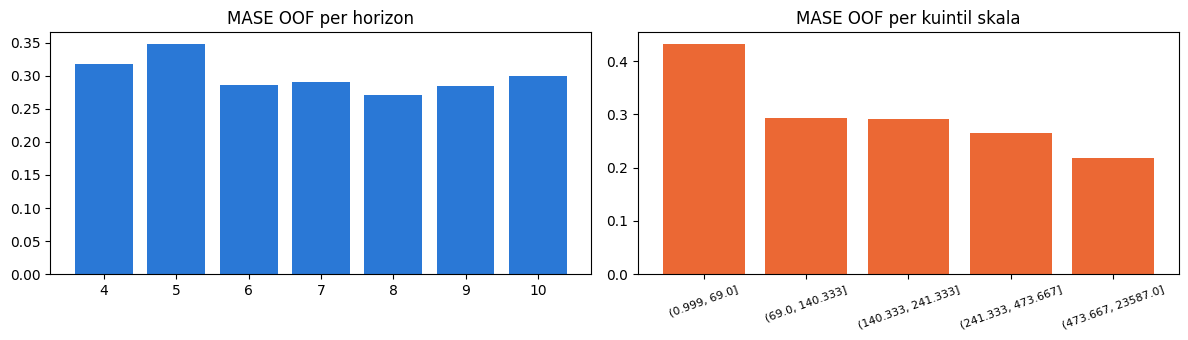

In [25]:
ev = trn[['movie_title', 'cinema_ids', 'h', 'fold', 'y', 'scale', 'D1']].copy()
ev['pred'] = oof_y
ev['err'] = np.abs(ev.y - ev.pred) / ev.scale
by_h = ev.groupby('h').err.mean()
ev['kuintil_skala'] = pd.qcut(ev.scale, 5, duplicates='drop')
by_scale = ev.groupby('kuintil_skala', observed=True).agg(mase=('err', 'mean'), porsi_error=('err', 'sum'),
                                                         frac_nol=('y', lambda s: (s == 0).mean()))
by_scale['porsi_error'] = by_scale.porsi_error / ev.err.sum()
print('MASE per fold:', [round(x, 5) for x in fold_scores])
print('MASE per horizon:', by_h.round(4).to_dict())
print(by_scale.round(3))
print('MASE target nol vs tidak:', ev.groupby(ev.y == 0).err.mean().round(4).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(by_h.index.astype(str), by_h.values, color='#2a78d6')
ax[0].set_title('MASE OOF per horizon')
ax[1].bar(range(len(by_scale)), by_scale.mase.values, color='#eb6834')
ax[1].set_xticks(range(len(by_scale)))
ax[1].set_xticklabels([str(i) for i in by_scale.index], rotation=20, fontsize=8)
ax[1].set_title('MASE OOF per kuintil skala')
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'eval_segments.png', dpi=110)
plt.show()

## Film dengan Error Terbesar

Retensi film (rata-rata target dibagi skala di D4 sampai D10) dibandingkan dengan prediksi untuk film penyumbang error terbesar, karena film menjelaskan sebagian besar variansi target.

                                 baris   mase  total_err  retensi_asli  retensi_pred  porsi_error
movie_title                                                                                      
SORE ISTRI DARI MASA DEPAN         609  2.308   1405.749         2.430         0.798        0.084
SAYAP SAYAP PATAH 2: OLIVIA        651  1.278    831.956         0.958         0.255        0.050
LILO & STITCH                      777  0.978    759.618         1.506         0.947        0.045
UNTIL DAWN                         406  1.477    599.586         0.870         0.637        0.036
THE SHADOWS EDGE                   756  0.540    408.184         1.332         1.027        0.024
WEAPONS                            693  0.521    361.194         1.446         1.051        0.022
SUKMA                              686  0.461    316.161         0.802         0.546        0.019
LA TAHZAN: CINTA, DOSA, LUKA...    770  0.379    292.134         0.842         0.531        0.017
PENGEPUNGAN DI BUKIT

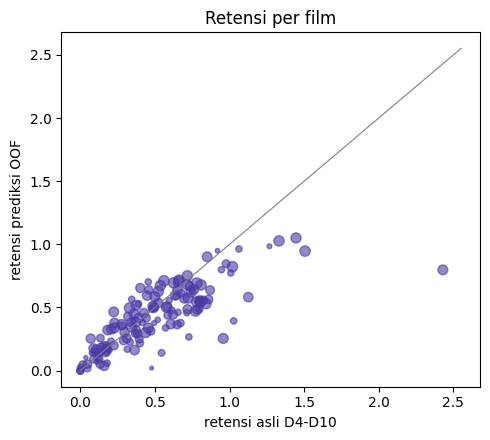

In [26]:
film_err = ev.groupby('movie_title').agg(baris=('err', 'size'), mase=('err', 'mean'), total_err=('err', 'sum'),
                                         retensi_asli=('y', 'sum'), retensi_pred=('pred', 'sum'))
scale_sum = ev.groupby('movie_title').scale.sum()
film_err['retensi_asli'] = film_err.retensi_asli / scale_sum
film_err['retensi_pred'] = film_err.retensi_pred / scale_sum
film_err['porsi_error'] = film_err.total_err / ev.err.sum()
print(film_err.sort_values('total_err', ascending=False).head(10).round(3))

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(film_err.retensi_asli, film_err.retensi_pred, s=np.sqrt(film_err.baris) * 2, alpha=0.6, color='#4a3aa7')
lim = max(film_err.retensi_asli.max(), film_err.retensi_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], color='gray', lw=0.8)
ax.set_xlabel('retensi asli D4-D10')
ax.set_ylabel('retensi prediksi OOF')
ax.set_title('Retensi per film')
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'eval_film_retention.png', dpi=110)
plt.show()

## Permutation Importance

Satu model dipasang pada fold latih 0 untuk horizon D8 (hari pergantian program), lalu setiap fitur diacak satu per satu di data validasi fold 0. Kenaikan MASE menunjukkan seberapa bergantung model pada fitur tersebut.

MASE dasar fold 0 D8: 0.1694 (895 s)
city_name_cat         0.0024
hol_weekday           0.0014
is_hol                0.0012
nat_show_d2           0.0007
cin_seats             0.0007
cal_w13               0.0007
show_d2               0.0005
tps_d3_vs_nat         0.0004
dow                   0.0004
nat_tix_adj_d1        0.0004
show_r31_vs_nat       0.0003
share_d3              0.0003
nat_tix_adj_r32       0.0003
d1_dow                0.0003
tix_adj_r31_vs_nat    0.0003
dtype: float64


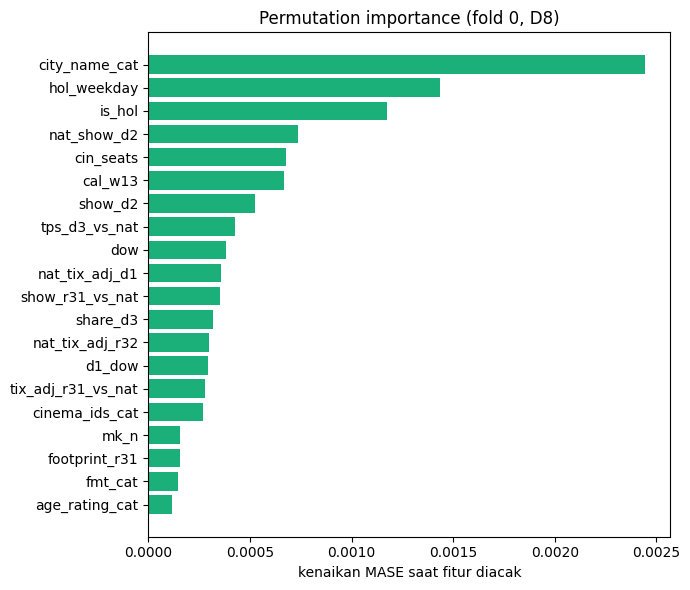

In [27]:
if CFG.RUN_XAI:
    rng = np.random.default_rng(CFG.SEED)
    tr0 = np.where((trn.fold.values != 0) & (h_tr == CFG.XAI_HORIZON))[0]
    va0 = np.where((trn.fold.values == 0) & (h_tr == CFG.XAI_HORIZON))[0]
    xai_model = make_model()
    xai_model.fit(trn.iloc[tr0][FEATURES].to_numpy(dtype=np.float32), r_all[tr0])
    X_va = trn.iloc[va0][FEATURES].to_numpy(dtype=np.float32)
    y_va, s_va, c_va = trn.y.values[va0], trn.scale.values[va0], c_tr[va0]

    def score_x(X):
        p = xai_model.predict(X, output_type=CFG.OUTPUT_TYPE) * c_va
        return mase(y_va, np.clip(p, 0, None) * s_va, s_va)

    base_score = score_x(X_va)
    importance = {}
    t0 = time.time()
    for j, f in enumerate(FEATURES):
        Xp = X_va.copy()
        Xp[:, j] = rng.permutation(Xp[:, j])
        importance[f] = score_x(Xp) - base_score
    importance = pd.Series(importance).sort_values(ascending=False)
    print(f'MASE dasar fold 0 D{CFG.XAI_HORIZON}: {base_score:.4f} ({time.time() - t0:.0f} s)')
    print(importance.head(15).round(4))

    top = importance.head(20)[::-1]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top.index, top.values, color='#1baf7a')
    ax.set_xlabel('kenaikan MASE saat fitur diacak')
    ax.set_title(f'Permutation importance (fold 0, D{CFG.XAI_HORIZON})')
    plt.tight_layout()
    plt.savefig(CFG.FIG_DIR / 'xai_permutation.png', dpi=110)
    plt.show()

#### Insights

> MASE OOF sekitar 0,30 dengan variasi antar fold yang besar (sekitar 0,20 sampai 0,37) karena komposisi film per fold berbeda. Error terkonsentrasi pada pasangan berskala kecil, di mana satu tiket bernilai besar relatif terhadap skala dan target sering nol.

> Sebagian besar error berasal dari film dengan nasib yang sulit ditebak dari tiga hari pertama, misalnya sleeper hit yang penjualannya naik berkali lipat di minggu kedua. Analisis batas atas menunjukkan bahwa walaupun retensi setiap film diketahui sempurna, MASE hanya turun ke sekitar 0,28, karena sisa galat berasal dari keputusan pencabutan per klaster.

> Permutation importance pada fold 0 horizon D8 (MASE dasar 0,169) memberi kenaikan MASE yang kecil untuk setiap fitur (tertinggi sekitar 0,002): kode kota, libur di hari kerja, status libur, total show nasional D2, dan kapasitas kursi klaster. Nilai yang kecil menunjukkan informasi tersebar di banyak fitur yang saling berkorelasi (level, tren, dan agregat nasional dalam beberapa versi), sehingga mengacak satu fitur mudah digantikan fitur lain. Permutasi satu per satu karena itu meremehkan kepentingan kelompok fitur dan hanya dipakai sebagai urutan kasar.

---

# Submission dan Kesimpulan <a name="8"></a>

---

## Submission

Prediksi test ditulis dengan format `id,total_ticket` dan divalidasi terhadap `sample_submission.csv`: jumlah baris 72.611, id identik, tanpa nilai kosong atau negatif.

In [28]:
submission = pd.DataFrame({'id': tst.id.values, 'total_ticket': test_y}).sort_values('id').reset_index(drop=True)
if not CFG.SMOKE_TEST:
    assert len(submission) == len(sample_submission) == 72611
    assert np.array_equal(submission.id.values, np.sort(sample_submission.id.values))
assert submission.total_ticket.notna().all() and (submission.total_ticket >= 0).all()
submission.to_csv(CFG.OUTPUT_DIR / 'submission.csv', index=False)
oof_table = trn[['movie_title', 'cinema_ids', 'h', 'fold', 'y', 'scale']].assign(pred=oof_y)
oof_table.to_csv(CFG.OUTPUT_DIR / 'oof.csv', index=False)
print(submission.head())
print(submission.total_ticket.describe().round(2))
print('tersimpan di', CFG.OUTPUT_DIR / 'submission.csv')

   id  total_ticket
0   1     36.405648
1   2     24.284737
2   3      0.083932
3   4      0.000000
4   5      0.000000
count    72611.00
mean       148.36
std        501.09
min          0.00
25%          0.08
50%         32.42
75%        128.30
max      31478.33
Name: total_ticket, dtype: float64
tersimpan di E:\datsci\joint\joints\notebooks\output_tabpfn35\submission.csv


## Kesimpulan

Pipeline ini merekonstruksi sampel latih dengan aturan yang sama seperti panitia (D1 rilis luas, pasangan laku di D3, target nol diisi eksplisit), membersihkan outage Juni 2025 dan akhir pekan preview, lalu membangun 92 fitur dari tiga hari pertama. Target dinormalisasi dengan skala dan bobot kalender, sehingga model hanya perlu mempelajari bentuk retensi, sementara efek hari, libur, libur sekolah, dan Ramadan ditangani secara struktural.

TabPFN-3.5 per horizon dengan prediksi median menghasilkan MASE OOF sekitar 0,30 pada validasi per film, lebih baik dari LightGBM (0,316), XGBoost, CatBoost, dan foundation model tabular lain yang diuji. Sumber error terbesar adalah ketidakpastian nasib film di minggu kedua dan keputusan pencabutan per klaster pada hari pergantian program, yang hanya sebagian dapat dibaca dari okupansi, jumlah show, dan tren D1 sampai D3.